In [1]:
import pandas as pd

In [6]:
df=pd.read_csv("online food delivery dataset.csv")
print (df.head())
print (df.shape)

   Age  Gender Marital Status Occupation  Monthly Income  \
0   20  Female         Single    Student       No Income   
1   24  Female         Single    Student  Below Rs.10000   
2   22    Male         Single    Student  Below Rs.10000   
3   22  Female         Single    Student       No Income   
4   22    Male         Single    Student  Below Rs.10000   

  Educational Qualifications  Family size Customer Type  latitude  longitude  \
0              Post Graduate            4      Frequent   12.9766    77.5993   
1                   Graduate            3       Regular   12.9770    77.5773   
2              Post Graduate            3       Regular   12.9551    77.6593   
3                   Graduate            6      Frequent   12.9473    77.5616   
4              Post Graduate            4      Frequent   12.9850    77.5533   

   Pin code Output   Feedback Unnamed: 13  
0    560001    Yes   Positive         Yes  
1    560009    Yes   Positive         Yes  
2    560017    Yes  Negati

In [8]:
df.drop(columns=["Unnamed: 13"], inplace=True)
print(df.shape)

(388, 13)


In [9]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
dtype: int64

Duplicate Rows:
103


In [12]:
duplicates=df[df.duplicated(keep=False)]
print(duplicates.shape)
print(duplicates.head(20))

(169, 13)
    Age  Gender Marital Status Occupation   Monthly Income  \
2    22    Male         Single    Student   Below Rs.10000   
3    22  Female         Single    Student        No Income   
4    22    Male         Single    Student   Below Rs.10000   
5    27  Female        Married   Employee  More than 50000   
6    22    Male         Single    Student        No Income   
7    24  Female         Single    Student        No Income   
8    23  Female         Single    Student        No Income   
9    23  Female         Single    Student        No Income   
10   22  Female         Single    Student        No Income   
11   23    Male         Single    Student   Below Rs.10000   
12   23    Male         Single    Student        No Income   
13   21    Male         Single    Student        No Income   
17   23  Female         Single    Student        No Income   
20   24    Male         Single    Student        No Income   
33   22  Female         Single    Student   10001 to 25000  

In [15]:
freq=df.value_counts().reset_index(name="count").sort_values("count", ascending= False)
print(freq.head(15))

    Age  Gender Marital Status      Occupation   Monthly Income  \
0    23  Female         Single         Student        No Income   
2    22  Female         Single         Student        No Income   
1    23  Female         Single         Student        No Income   
25   24    Male         Single         Student        No Income   
19   26  Female        Married  Self Employeed   10001 to 25000   
20   23    Male         Single         Student        No Income   
21   24  Female         Single  Self Employeed   25001 to 50000   
22   24  Female         Single         Student        No Income   
23   25    Male         Single  Self Employeed  More than 50000   
27   22  Female         Single         Student        No Income   
26   24    Male         Single         Student        No Income   
17   26    Male        Married        Employee  More than 50000   
28   25  Female         Single         Student        No Income   
29   20    Male         Single         Student        No Incom

In [16]:
df=df.drop_duplicates().reset_index(drop=True)
print(df.shape)
print("Duplicates: ", df.duplicated().sum())

(285, 13)
Duplicates:  0


In [17]:
for col in df.select_dtypes("object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())   


--- Gender ---
Male      164
Female    121
Name: Gender, dtype: int64

--- Marital Status ---
Single               189
Married               87
Prefer not to say      9
Name: Marital Status, dtype: int64

--- Occupation ---
Student           144
Employee           94
Self Employeed     38
House wife          9
Name: Occupation, dtype: int64

--- Monthly Income ---
No Income          131
25001 to 50000      52
More than 50000     47
10001 to 25000      36
Below Rs.10000      19
Name: Monthly Income, dtype: int64

--- Educational Qualifications ---
Graduate         126
Post Graduate    125
Ph.D              21
School            11
Uneducated         2
Name: Educational Qualifications, dtype: int64

--- Customer Type ---
Regular     162
Frequent    105
New          18
Name: Customer Type, dtype: int64

--- Output ---
Yes    217
No      68
Name: Output, dtype: int64

--- Feedback ---
Positive     231
Negative      54
Name: Feedback, dtype: int64


In [19]:
for col in df.select_dtypes(include="object").columns:
    df[col]=df[col].str.strip()
df["Occupation"]=df["Occupation"].replace({
    "Self Employeed": "Self Employed",
    "House wife": "Housewife"
})

In [20]:
print(df["Occupation"].value_counts())

Student          144
Employee          94
Self Employed     38
Housewife          9
Name: Occupation, dtype: int64


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         285 non-null    int64  
 1   Gender                      285 non-null    object 
 2   Marital Status              285 non-null    object 
 3   Occupation                  285 non-null    object 
 4   Monthly Income              285 non-null    object 
 5   Educational Qualifications  285 non-null    object 
 6   Family size                 285 non-null    int64  
 7   Customer Type               285 non-null    object 
 8   latitude                    285 non-null    float64
 9   longitude                   285 non-null    float64
 10  Pin code                    285 non-null    int64  
 11  Output                      285 non-null    object 
 12  Feedback                    285 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [22]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,285.000000,285.000000,285.000000,285.000000,285.000000
mean,24.677193,3.270175,12.973429,77.597593,560037.280702
std,3.040977,1.361178,0.043964,0.053557,30.738306
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.943800,77.563500,560010.000000
50%,24.000000,3.000000,12.977000,77.587700,560028.000000
75%,26.000000,4.000000,12.998000,77.622700,560066.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [23]:
df.head(5)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive


In [24]:
output_counts=df["Output"].value_counts()
output_pct=df["Output"].value_counts(normalize=True)*100
print(output_counts)
print(output_pct.round(2))

Yes    217
No      68
Name: Output, dtype: int64
Yes    76.14
No     23.86
Name: Output, dtype: float64


In [25]:
ct=pd.crosstab(
df["Customer Type"],
df["Output"],
normalize="index"
)*100
print(ct.round(2))

Output            No    Yes
Customer Type              
Frequent       24.76  75.24
New            27.78  72.22
Regular        22.84  77.16


In [27]:
occupation_output=pd.crosstab(
df["Occupation"],
df["Output"],
normalize="index"
)*100
print(occupation_output)

Output                No        Yes
Occupation                         
Employee       36.170213  63.829787
Housewife      22.222222  77.777778
Self Employed  36.842105  63.157895
Student        12.500000  87.500000


In [28]:
income_ouput=pd.crosstab(
df["Monthly Income"],
df["Output"],
normalize="index")*100
print(income_ouput)

Output                  No        Yes
Monthly Income                       
10001 to 25000   25.000000  75.000000
25001 to 50000   36.538462  63.461538
Below Rs.10000   21.052632  78.947368
More than 50000  36.170213  63.829787
No Income        14.503817  85.496183


In [29]:
student_income = pd.crosstab(
    [df["Occupation"], df["Monthly Income"]],
    df["Output"],
    normalize="index"
) * 100

print(student_income.round(2))

Output                            No     Yes
Occupation    Monthly Income                
Employee      10001 to 25000   23.81   76.19
              25001 to 50000   36.84   63.16
              Below Rs.10000   66.67   33.33
              More than 50000  37.93   62.07
Housewife     No Income        22.22   77.78
Self Employed 10001 to 25000   30.00   70.00
              25001 to 50000   45.45   54.55
              More than 50000  35.29   64.71
Student       10001 to 25000   20.00   80.00
              25001 to 50000    0.00  100.00
              Below Rs.10000    0.00  100.00
              More than 50000   0.00  100.00
              No Income        13.93   86.07


In [30]:
counts = pd.crosstab(
    [df["Occupation"], df["Monthly Income"]],
    df["Output"]
)

print(counts)

Output                         No  Yes
Occupation    Monthly Income          
Employee      10001 to 25000    5   16
              25001 to 50000   14   24
              Below Rs.10000    4    2
              More than 50000  11   18
Housewife     No Income         2    7
Self Employed 10001 to 25000    3    7
              25001 to 50000    5    6
              More than 50000   6   11
Student       10001 to 25000    1    4
              25001 to 50000    0    3
              Below Rs.10000    0   13
              More than 50000   0    1
              No Income        17  105


In [32]:
age_stats=df.groupby("Output")["Age"].agg(
["count","mean","median","min",max]
)
print(age_stats)

        count       mean  median  min  max
Output                                    
No         68  25.897059    26.0   19   33
Yes       217  24.294931    24.0   18   32


In [33]:
df["Age Group"]=pd.cut(
df["Age"],
bins=[0,20,25,30,35,100],
labels=["<=20", "21-25", "26-30", "31-35", "36+"]
)

In [34]:
age_output=pd.crosstab(
df["Age Group"],
df["Output"],
normalize="index")

In [37]:
print((age_output*100).round(2))

Output        No    Yes
Age Group              
<=20       16.67  83.33
21-25      14.75  85.25
26-30      50.00  50.00
31-35      20.00  80.00


In [38]:
age_counts=pd.crosstab(
df["Age Group"],
df["Output"])
print(age_counts)

Output     No  Yes
Age Group         
<=20        2   10
21-25      27  156
26-30      35   35
31-35       4   16


In [39]:
age_occupation = pd.crosstab(
    df["Age Group"],
    df["Occupation"],
    normalize="index"
) * 100

print(age_occupation.round(2))

Occupation  Employee  Housewife  Self Employed  Student
Age Group                                              
<=20            0.00       0.00            0.0   100.00
21-25          22.40       0.55            8.2    68.85
26-30          58.57       2.86           30.0     8.57
31-35          60.00      30.00           10.0     0.00


In [40]:
age_occ_output = pd.crosstab(
    [df["Age Group"], df["Occupation"]],
    df["Output"],
    normalize="index"
) * 100

print(age_occ_output.round(2))

Output                      No     Yes
Age Group Occupation                  
<=20      Student        16.67   83.33
21-25     Employee       19.51   80.49
          Housewife       0.00  100.00
          Self Employed  26.67   73.33
          Student        11.90   88.10
26-30     Employee       56.10   43.90
          Housewife      50.00   50.00
          Self Employed  47.62   52.38
          Student        16.67   83.33
31-35     Employee       25.00   75.00
          Housewife      16.67   83.33
          Self Employed   0.00  100.00


In [41]:
age_occ_counts = pd.crosstab(
    [df["Age Group"], df["Occupation"]],
    df["Output"]
)

print(age_occ_counts)

Output                   No  Yes
Age Group Occupation            
<=20      Student         2   10
21-25     Employee        8   33
          Housewife       0    1
          Self Employed   4   11
          Student        15  111
26-30     Employee       23   18
          Housewife       1    1
          Self Employed  10   11
          Student         1    5
31-35     Employee        3    9
          Housewife       1    5
          Self Employed   0    2


In [42]:
feedback_counts = pd.crosstab(
    df["Feedback"],
    df["Output"]
)

print(feedback_counts)

Output    No  Yes
Feedback         
Negative  39   15
Positive  29  202


In [43]:
feedback_output = pd.crosstab(
    df["Feedback"],
    df["Output"],
    normalize="index"
) * 100

print(feedback_output.round(2))

Output       No    Yes
Feedback              
Negative  72.22  27.78
Positive  12.55  87.45


In [44]:
family_counts = pd.crosstab(
    df["Family size"],
    df["Output"]
)

print(family_counts)

Output       No  Yes
Family size         
1             5   13
2            20   55
3            17   70
4             6   39
5            11   26
6             9   14


In [45]:
marital_counts = pd.crosstab(
    df["Marital Status"],
    df["Output"]
)

print(marital_counts)

Output             No  Yes
Marital Status            
Married            34   53
Prefer not to say   5    4
Single             29  160


In [46]:
marital_output = pd.crosstab(
    df["Marital Status"],
    df["Output"],
    normalize="index"
) * 100

print(marital_output.round(2))

Output                No    Yes
Marital Status                 
Married            39.08  60.92
Prefer not to say  55.56  44.44
Single             15.34  84.66


In [47]:
marital_occ_output = pd.crosstab(
    [df["Marital Status"], df["Occupation"]],
    df["Output"],
    normalize="index"
) * 100

print(marital_occ_output.round(2))

Output                              No     Yes
Marital Status    Occupation                  
Married           Employee       42.86   57.14
                  Housewife      25.00   75.00
                  Self Employed  44.00   56.00
                  Student         0.00  100.00
Prefer not to say Employee       66.67   33.33
                  Housewife       0.00  100.00
                  Self Employed  50.00   50.00
Single            Employee       23.08   76.92
                  Self Employed  18.18   81.82
                  Student        12.95   87.05


In [48]:
marital_occ_counts = pd.crosstab(
    [df["Marital Status"], df["Occupation"]],
    df["Output"]
)

print(marital_occ_counts)

Output                           No  Yes
Marital Status    Occupation            
Married           Employee       21   28
                  Housewife       2    6
                  Self Employed  11   14
                  Student         0    5
Prefer not to say Employee        4    2
                  Housewife       0    1
                  Self Employed   1    1
Single            Employee        9   30
                  Self Employed   2    9
                  Student        18  121


In [49]:
from scipy.stats import chi2_contingency

categorical_cols = [
    "Gender",
    "Marital Status",
    "Occupation",
    "Monthly Income",
    "Educational Qualifications",
    "Customer Type",
    "Feedback"
]

results = []

for col in categorical_cols:
    table = pd.crosstab(df[col], df["Output"])

    chi2, p, dof, expected = chi2_contingency(table)

    results.append({
        "Variable": col,
        "Chi2": chi2,
        "p_value": p,
        "DOF": dof
    })

chi_results = pd.DataFrame(results)

print(
    chi_results
    .sort_values("p_value")
    .round(6)
)

                     Variable       Chi2   p_value  DOF
6                    Feedback  82.523129  0.000000    1
1              Marital Status  23.616175  0.000007    2
2                  Occupation  21.608900  0.000079    3
3              Monthly Income  14.942146  0.004823    4
4  Educational Qualifications   7.516382  0.110989    4
0                      Gender   0.210000  0.646768    1
5               Customer Type   0.291961  0.864175    2


In [50]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    r, k = table.shape

    return np.sqrt(
        chi2 /
        (n * min(k - 1, r - 1))
    )


categorical_cols = [
    "Gender",
    "Marital Status",
    "Occupation",
    "Monthly Income",
    "Educational Qualifications",
    "Customer Type",
    "Feedback"
]

results = []

for col in categorical_cols:

    v = cramers_v(
        df[col],
        df["Output"]
    )

    results.append({
        "Variable": col,
        "Cramers_V": v
    })


cramers_results = pd.DataFrame(results)

cramers_results = (
    cramers_results
    .sort_values(
        "Cramers_V",
        ascending=False
    )
    .reset_index(drop=True)
)

print(cramers_results.round(4))

                     Variable  Cramers_V
0                    Feedback     0.5381
1              Marital Status     0.2879
2                  Occupation     0.2754
3              Monthly Income     0.2290
4  Educational Qualifications     0.1624
5               Customer Type     0.0320
6                      Gender     0.0271


In [51]:
feature_rank = pd.merge(
    chi_results[["Variable", "Chi2", "p_value"]],
    cramers_results[["Variable", "Cramers_V"]],
    on="Variable"
)

feature_rank = feature_rank.sort_values(
    "Cramers_V",
    ascending=False
).reset_index(drop=True)

# إضافة وصف بسيط لقوة العلاقة
def strength(v):
    if v < 0.10:
        return "Very Weak"
    elif v < 0.30:
        return "Weak-Moderate"
    elif v < 0.50:
        return "Moderate"
    else:
        return "Strong"

feature_rank["Strength"] = feature_rank["Cramers_V"].apply(strength)

# هل العلاقة ذات دلالة إحصائية؟
feature_rank["Significant"] = feature_rank["p_value"].apply(
    lambda x: "Yes" if x < 0.05 else "No"
)

print(feature_rank.round(4))

                     Variable     Chi2  p_value  Cramers_V       Strength  \
0                    Feedback  82.5231   0.0000     0.5381         Strong   
1              Marital Status  23.6162   0.0000     0.2879  Weak-Moderate   
2                  Occupation  21.6089   0.0001     0.2754  Weak-Moderate   
3              Monthly Income  14.9421   0.0048     0.2290  Weak-Moderate   
4  Educational Qualifications   7.5164   0.1110     0.1624  Weak-Moderate   
5               Customer Type   0.2920   0.8642     0.0320      Very Weak   
6                      Gender   0.2100   0.6468     0.0271      Very Weak   

  Significant  
0         Yes  
1         Yes  
2         Yes  
3         Yes  
4          No  
5          No  
6          No  


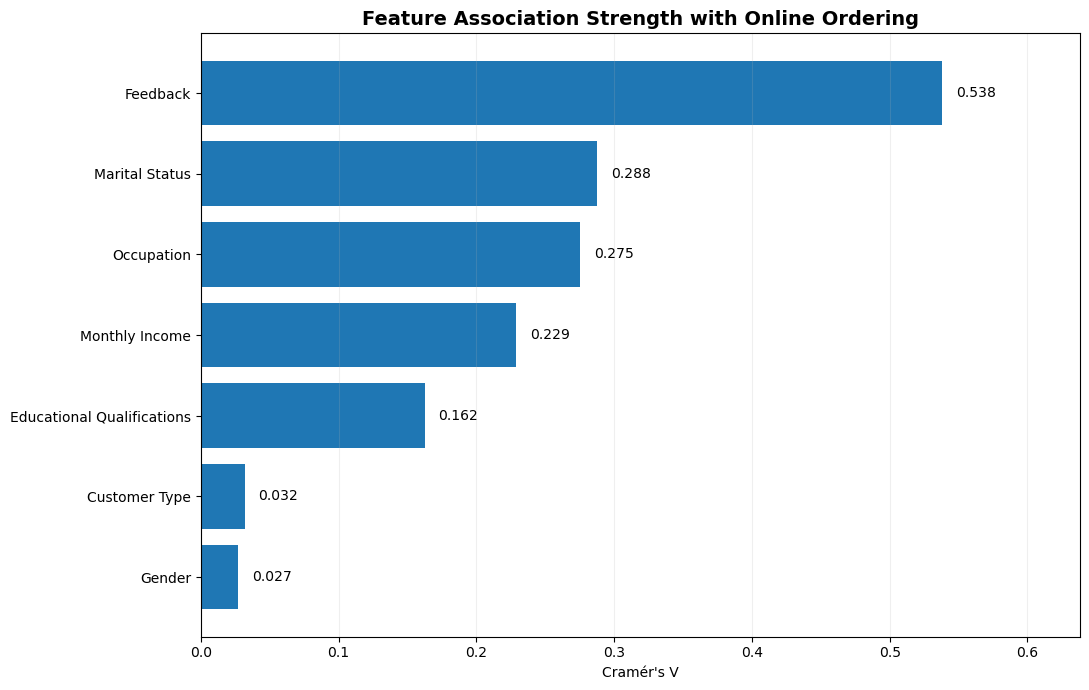

In [53]:
import matplotlib.pyplot as plt

plot_data = feature_rank.sort_values(
    "Cramers_V",
    ascending=True
).copy()

plt.figure(figsize=(11, 7))

bars = plt.barh(
    plot_data["Variable"],
    plot_data["Cramers_V"]
)

plt.xlabel("Cramér's V")
plt.ylabel("")
plt.title(
    "Feature Association Strength with Online Ordering",
    fontsize=14,
    fontweight="bold"
)

# كتابة القيمة بجانب كل عمود
for bar, value in zip(bars, plot_data["Cramers_V"]):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.xlim(
    0,
    plot_data["Cramers_V"].max() + 0.10
)

plt.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "feature_association_strength.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

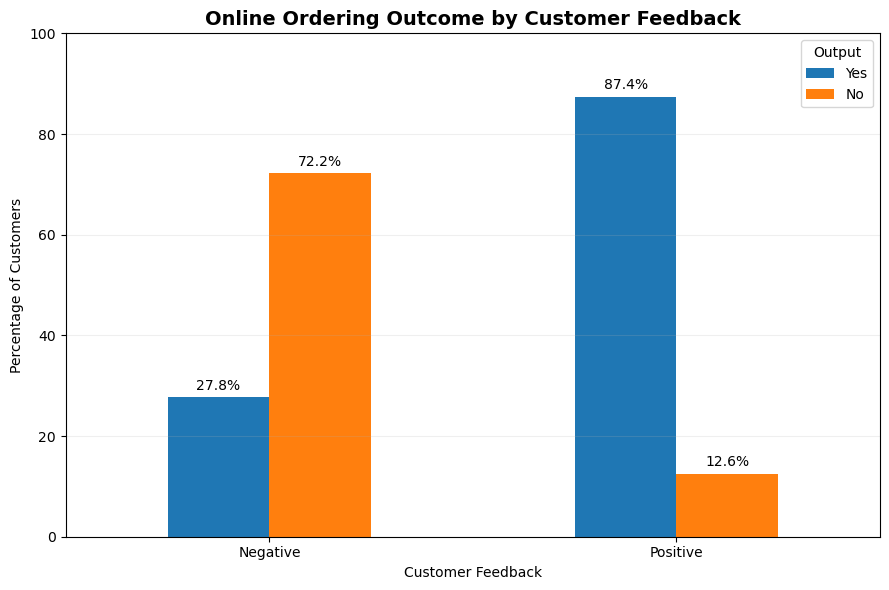

In [54]:

feedback_plot = pd.crosstab(
    df["Feedback"],
    df["Output"],
    normalize="index"
) * 100

feedback_plot = feedback_plot[["Yes", "No"]]

ax = feedback_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title(
    "Online Ordering Outcome by Customer Feedback",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customer Feedback")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.ylim(0, 100)

# كتابة النسب فوق الأعمدة
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.legend(
    title="Output"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "feedback_vs_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

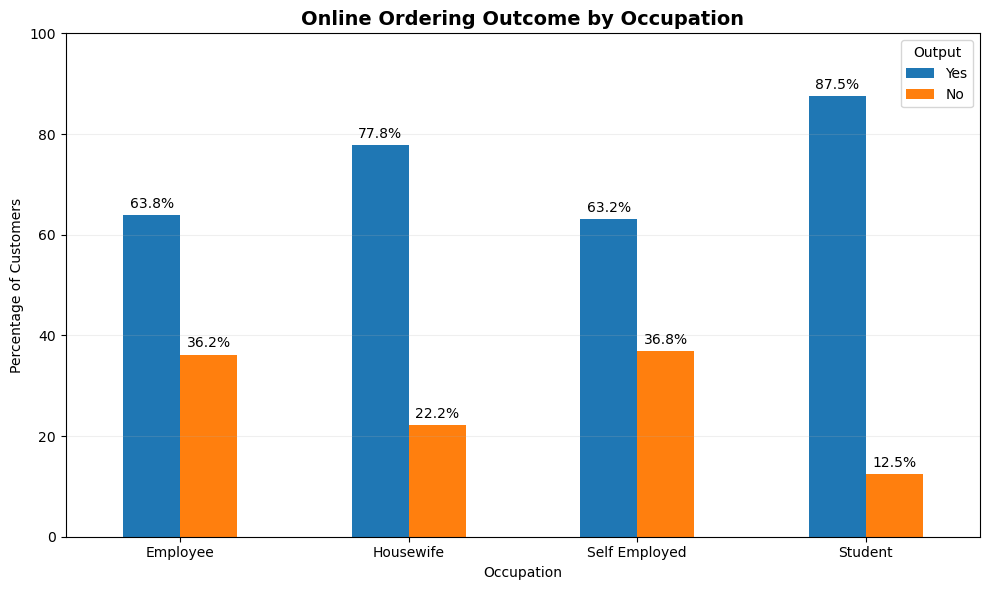

In [55]:

occupation_plot = pd.crosstab(
    df["Occupation"],
    df["Output"],
    normalize="index"
) * 100

occupation_plot = occupation_plot[["Yes", "No"]]

ax = occupation_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Online Ordering Outcome by Occupation",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Occupation")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)

plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.legend(
    title="Output"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "occupation_vs_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

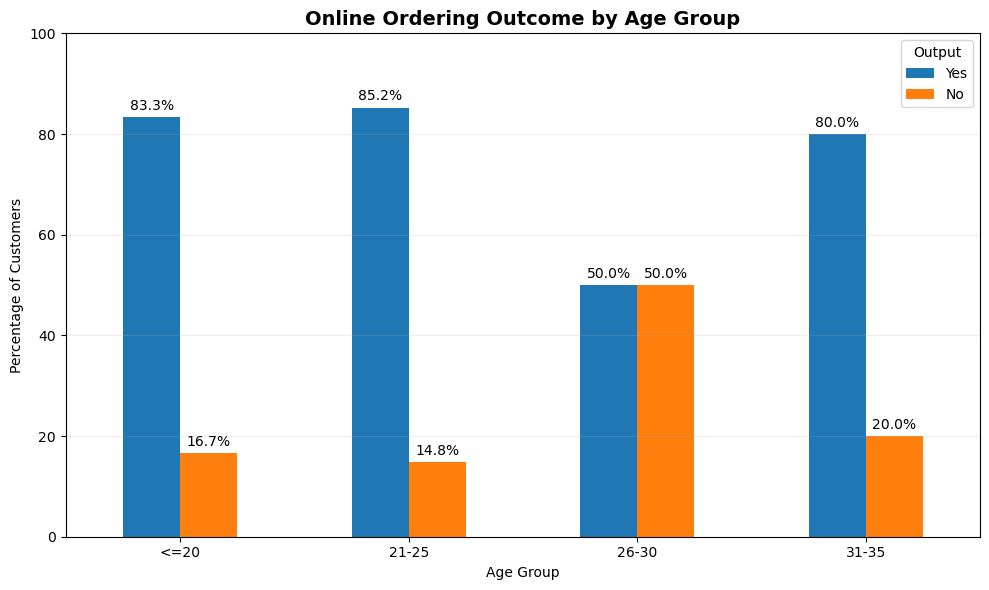

In [56]:
age_plot = pd.crosstab(
    df["Age Group"],
    df["Output"],
    normalize="index"
) * 100

age_plot = age_plot[["Yes", "No"]]

ax = age_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Online Ordering Outcome by Age Group",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age Group")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.legend(title="Output")
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()

plt.savefig(
    "age_group_vs_output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

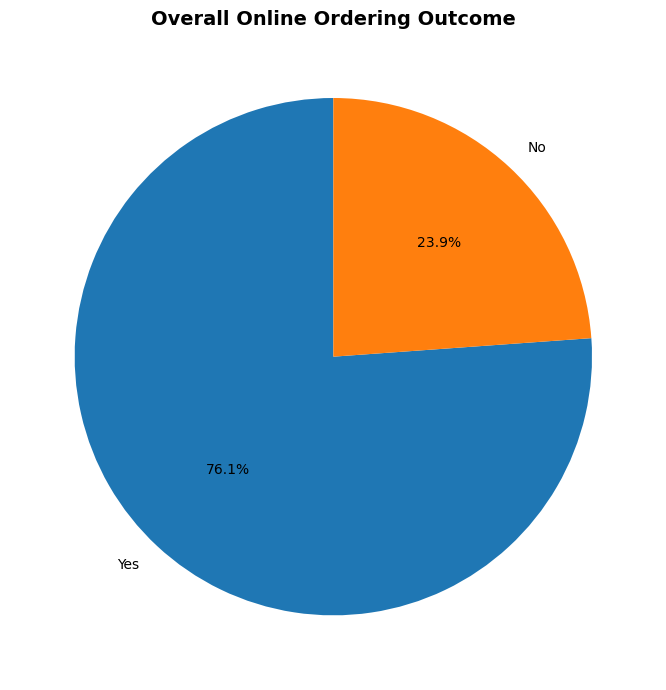

In [57]:
output_counts = df["Output"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    output_counts.values,
    labels=output_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Overall Online Ordering Outcome",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "output_distribution_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

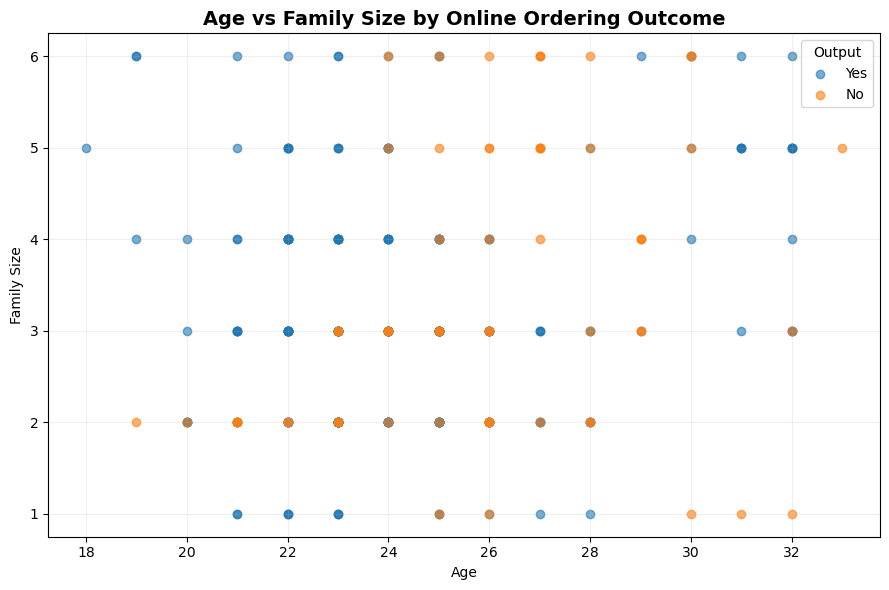

In [58]:

yes_df = df[df["Output"] == "Yes"]
no_df  = df[df["Output"] == "No"]

plt.figure(figsize=(9, 6))

plt.scatter(
    yes_df["Age"],
    yes_df["Family size"],
    alpha=0.6,
    label="Yes"
)

plt.scatter(
    no_df["Age"],
    no_df["Family size"],
    alpha=0.6,
    label="No"
)

plt.title(
    "Age vs Family Size by Online Ordering Outcome",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Age")
plt.ylabel("Family Size")

plt.legend(title="Output")
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "age_family_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

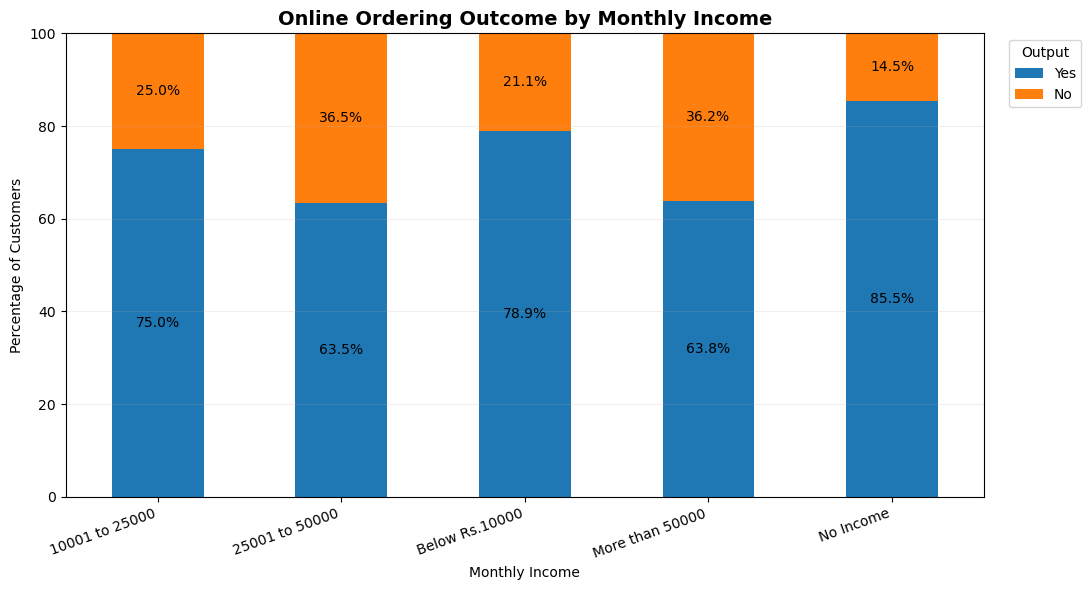

In [59]:
income_plot = pd.crosstab(
    df["Monthly Income"],
    df["Output"],
    normalize="index"
) * 100

income_plot = income_plot[["Yes", "No"]]

ax = income_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title(
    "Online Ordering Outcome by Monthly Income",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Monthly Income")
plt.ylabel("Percentage of Customers")

plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        label_type="center"
    )

plt.legend(
    title="Output",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "income_vs_output_stacked.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

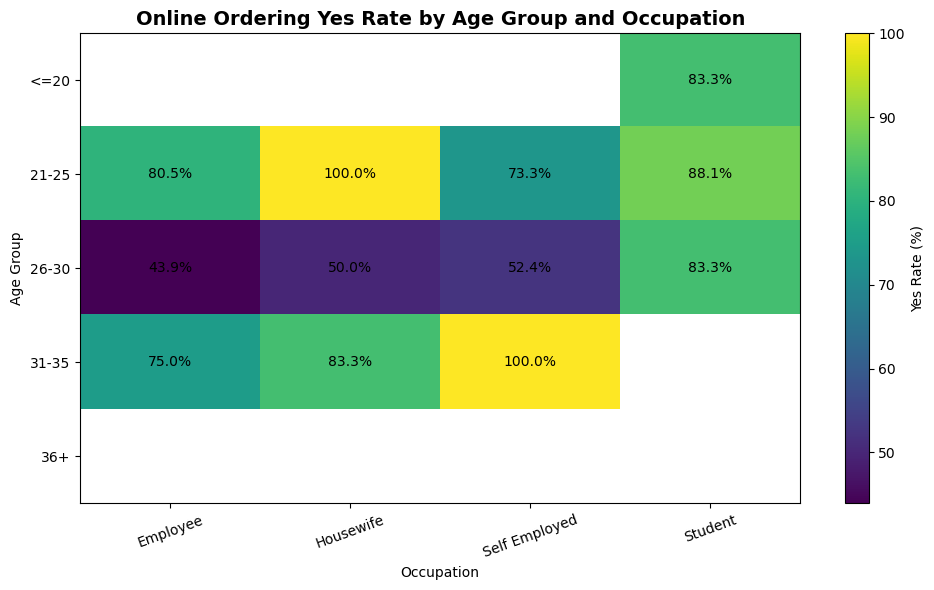

In [61]:

heat_data = (
    df.groupby(["Age Group", "Occupation"])["Output"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .unstack()
)

plt.figure(figsize=(10, 6))

plt.imshow(
    heat_data,
    aspect="auto"
)

plt.colorbar(label="Yes Rate (%)")

plt.xticks(
    range(len(heat_data.columns)),
    heat_data.columns,
    rotation=20
)

plt.yticks(
    range(len(heat_data.index)),
    heat_data.index
)

plt.title(
    "Online Ordering Yes Rate by Age Group and Occupation",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Occupation")
plt.ylabel("Age Group")

# كتابة النسب داخل الخلايا
for i in range(len(heat_data.index)):
    for j in range(len(heat_data.columns)):
        value = heat_data.iloc[i, j]

        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    "age_occupation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()